In [35]:
import numpy as np
import matplotlib.pyplot as plt

# PageRank


## Introduction ##


### **PageRank (PR)** is an algorithm used by Google Search to rank web pages in their search engine results. ###

### It is named after both the term "web page" and co-founder [Larry Page](https://en.wikipedia.org/wiki/Larry_Page). ###

### PageRank is a way of measuring the importance of website pages. ###



### According to Google: ###


#### _PageRank works by counting the number and quality of links to a page to determine a rough estimate of how important the website is._ ####

#### _The underlying assumption is that more important websites are likely to receive more links from other websites._ ####




## Algorithm Description ## 


### **PageRank** is a link analysis algorithm that assigns a numerical weighting to each element of a hyperlinked set of documents, with the purpose of measuring its relative importance within the set. ###
### The algorithm may be applied to any collection of entities with reciprocal quotations and references. ###
### The numerical weight that it assigns to any given element $E$ is referred to as the _PageRank_ of $E$ and denoted by $PR(E)$. ###
### A _PageRank_ results from a mathematical algorithm based on the [Webgraph](https://en.wikipedia.org/wiki/Webgraph), created by all World Wide Web pages as nodes and hyperlinks as edges. ###
### The rank value indicates an importance of a particular page. A hyperlink to a page counts as a vote of support. ###
### The _PageRank_ of a page is defined recursively and depends on the number and PageRank metric of all pages that link to it ("incoming links"). ###
### A page that is linked to by many pages with high _PageRank_ receives a high rank itself. ###

In [40]:
def pagerank(M, d: float = 0.85):
    """PageRank algorithm with explicit number of iterations. Returns ranking of nodes (pages) in the adjacency matrix.

    Parameters
    ----------
    M : numpy array, mandatory
        adjacency matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1
    d : float, optional
        damping factor, by default 0.85

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank from [0, 1],

    """
    # N = Number of pages (nodes)
    N = M.shape[1]
    
    # w = Initial rank vector
    # We assume all pages are equally important
    w = np.ones(N) / N

    # Applying the damping factor
    # Represents the probability a user follows a link
    M_hat = d * M

    # Page rank received from incoming links
    link_contribution = M_hat @ w

    # Probability of randomly jumping to any page.
    # Adds small probability to every page
    teleportation_probability = (1 - d) / N

    # First rank update
    v = link_contribution + teleportation_probability
    
    # Algorithm runs until convergence
    # w - old rank
    # v - new rank
    # Repeating until difference is smaller than 1e-10
    while np.linalg.norm(w - v) >= 1e-10:
        # Update old vector
        w = v

        # Recalculate rank
        v = M_hat @ w + (1 - d) / N
    
    # Return final PageRank vector
    return v

In [55]:
# The matrix is always square, because it represents transitions between the same set of pages
# Every column must sum to 1
M = np.array([
    [0.0, 0.5, 0.0, 0.0, 0.2, 0.1],
    [0.5, 0.0, 0.3, 0.0, 0.2, 0.2],
    [0.5, 0.0, 0.0, 0.5, 0.2, 0.0],
    [0.0, 0.5, 0.4, 0.0, 0.0, 0.3],
    [0.0, 0.0, 0.3, 0.5, 0.3, 0.3],
    [0.0, 0.0, 0.0, 0.0, 0.1, 0.1]
])

In [ ]:
# For checking Matrix is correct, sum 

In [54]:
page_rank_result = pagerank(M)

In [49]:
page_rank_result

array([0.14691221, 0.18651331, 0.20517423, 0.18636381, 0.22665834,
       0.0483781 ])

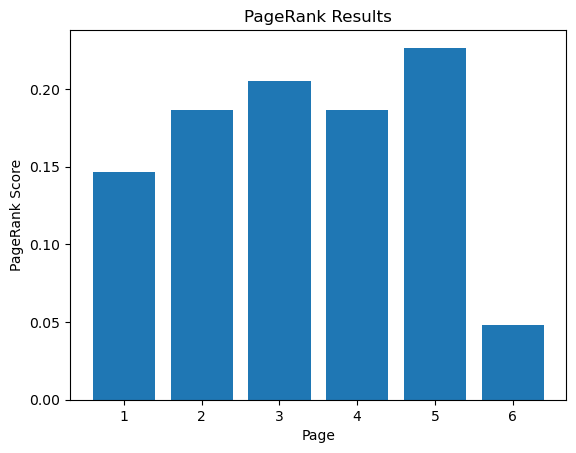

In [52]:
pages = np.arange(1, len(page_rank_result) + 1)

plt.bar(pages, page_rank_result)

plt.xlabel("Page")
plt.ylabel("PageRank Score")
plt.title("PageRank Results")

plt.xticks(pages)

plt.show()

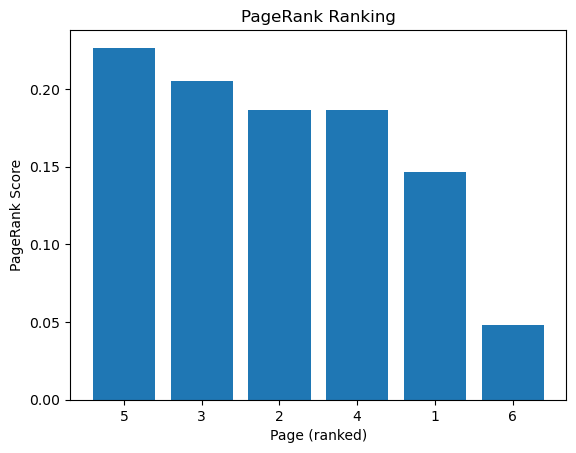

In [51]:
sorted = np.argsort(page_rank_result)[::-1]

plt.bar(range(len(page_rank_result)), page_rank_result[sorted])
plt.xticks(range(len(page_rank_result)), sorted + 1)

plt.xlabel("Page (ranked)")
plt.ylabel("PageRank Score")
plt.title("PageRank Ranking")

plt.show()